In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from astropy.table import Table,hstack
from scipy.optimize import minimize
import catalogue_analysis as ca
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=100, Om0=0.313, Tcmb0=2.725)   #Standard Planck Cosmology in Mpc/h units


In [3]:
#Load SDSS data with selection cuts applied

#Check the redshift values that corrrespond to the 10 and 150 Mpc/h cuts applied in lowz NYU-VAGC
print("distance",cosmo.comoving_distance(0.051))
print("distance",cosmo.comoving_distance(0.0035))

# Read NYU-VAGC lowz  at  https://sdss.physics.nyu.edu/vagc-dr6/vagc0/lowz/lowz-catalog.dr6.fits
sdss_full=Table.read("sdata/lowz_catalog.dr6.fits")
mask = (sdss_full["ZDIST"]>0.0035) & (sdss_full["ZDIST"]<0.051) & (sdss_full["VAGC_SELECT"]==7) & (sdss_full["SERSIC_N"][:,2]<2.0)
print("retained:",mask.sum())
sdss=sdss_full[mask].copy()
sdss["rmag_petro"]=22.5 -2.5*np.log10(np.maximum(1.0e-10,sdss['PETROFLUX'][:,2]))                                                   #- sdss['EXTINCTION'][:,2] uncomment this if PETROFLUX is not already dust corrected
sdss["mu50sec"]=sdss["rmag_petro"] + 2.5*np.log10(2*np.pi*(sdss['PETROTH50'][:,2]**2))


sdss.info("stats")

distance 151.04617750850034 Mpc
distance 10.484107479753796 Mpc
retained: 42746
<Table length=42746>
      name          mean        std         min         max     n_bad
--------------- ----------- ----------- ----------- ----------- -----
OBJECT_POSITION 1.14412e+06      668841       28952 2.58227e+06     0
          ICOMB      315022      169332         154      610203     0
         SECTOR     3922.06     2137.48           1        7694     0
    VAGC_SELECT           7           0           7           7     0
       FGOTMAIN    0.901514   0.0756828   0.0348837           1     0
           MMAX     17.7547   0.0373657       17.59     17.8098     0
             RA     179.925     59.6513  0.00876809     359.922     0
            DEC     26.4948     19.2881    -11.2024     68.6506     0
            RUN     3424.56     1224.16         727        6162     0
          RERUN          --          --          --          --     0
         CAMCOL      3.5386     1.60135           1        

/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


In [4]:
# Blanton (2005) relation between absolute magnitude and Surface brightness
def Blanton_2005(Mag_Petro):
    mubar50_Petro=20.56+0.45*(Mag_Petro+20.5) # Blanton (2005) relation
    sigmu=0.58+0.086*(Mag_Petro+20.5) #Blanton (2005) relation has beta=0.081 rather than 0.086
    Reff_Petro= Reff(mubar50_Petro,Mag_Petro)
    return mubar50_Petro,Reff_Petro,sigmu


# Various conversion functions to go between total and Petrosian quantities for objcets with Sersic profiles.    

def dMag_Petro(n_Sersic): # The difference between Petrosian and total magnitude for a Sersic Profile
    dMag_Petro =0.05+0.1*(n_Sersic-1)   # Approximation given by copilot quotes Driver paper
    return dMag_Petro

def Reff_true(Reff_Petro,n_Sersic):
    Reff_true=Reff_Petro * R50_over_R50PETRO(n_Sersic)
    return Reff_true
    
def R50_over_R50PETRO(n_Sersic):
    ratio= (1+0.23*(n_Sersic-1)) # Copilot approximation based on Driver paper (Good to ~5% 1<n<4)
    return ratio
    
def Reff(mu50,mag):
    # This works either for total/model apparent magnitudes or Petrosian apparent magnitudes provide the 50 in mu50 refers to 50% of the corresponding flux
    # We can compute the half light radius of the galaxy as in term of the Petrosian Flux (in nano-maggies)
    # mu50_Petro = 22.5 -2.5 log ( 0.5 F_Petro / pi Reff^2) while
    # Mag_Petro = 22.5 -2.5 log ( F_Petro )
    # Hence eliminating F_Petro and making Reff the subject we have
    Reff= ( 10.0**(0.2*(mu50-mag)) ) / np.sqrt(2.0*np.pi) 
    return Reff



In [5]:
#Read the DESI BGS Augmented data catalogue
dat=Table.read('sdata/BGS_Y3_26Mar2026.fits')
#Compute PETRO_ABSMAG_RP1 and PETRO_SB from total versions and SERSIC index
dat["PETRO_ABSMAG_RP1"]=dat["ABSMAG_RP1"]+dMag_Petro(dat["SERSIC"])
dat["PETRO_rmag"]=dat["rmag"]+dMag_Petro(dat["SERSIC"])
dat["R50"]=Reff(dat["SB"],dat["rmag"])
dat['PETRO_R50']=dat["R50"]/R50_over_R50PETRO(dat["SERSIC"])
dat["PETRO_SB"]=dat["PETRO_rmag"] + 2.5*np.log10(2*np.pi*(dat['PETRO_R50']**2))
dat["ABSMAG_RP1"]+dMag_Petro(dat["SERSIC"])

dat.info('stats')

<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213476    0.104427   0.00200603    0.599956
             NTILE      2.43434    0.916934            1           5
                RA      183.078     91.2515  0.000108207         360
               DEC      21.9899     23.0655     -19.5559     79.2584
           PHOTSYS           --          --           --          --
  FRAC_TLOBS_TILES     0.984397    0.027012     0.333333           1
      WEIGHT_ZFAIL      1.00127  0.00523178            1     1.19871
        BITWEIGHTS -5.27255e+14 3.02575e+18 -9.22337e+18 9.22337e+18
          PROB_OBS       0.8551    0.209397            0           1
            WEIGHT      1.30432    0.790294            1     74.1026
       WEIG

In [6]:
regions=('S','N')

# Set up jackknife region limits to equally split up the randoms provided
# and assign unique indices to each region for both data and randoms
njack_S=0
dat['ijack']=-999  # default to mean unassigned
for reg in regions:
    regmask = (dat['reg']==reg)    
    print('Processing region ',reg)
    if (reg=='S'):
      # set up the RA and dec boundaries  
      njack_S,limits_S=ca.solve_jackknife_nonsq(dat[regmask], ndiv_ra=4, ndiv_dec=5, offset=275)
      # assign data to the same regions
      ca.set_jackknife(dat, regmask, limits_S, 0, njack_S)
    else: 
      # set up the RA and dec boundaries   
      njack_N,limits_N=ca.solve_jackknife_nonsq(dat[regmask], ndiv_ra=3, ndiv_dec=3, offset=275)
      # assign data to the same regions  
      ca.set_jackknife(dat, regmask, limits_N, njack_S, njack_N)

Processing region  S
length of data table: 5436052
The number of objects assigned in each region falls in the range: 271802  to  271803
Attempting to assign the remaining unassigned   5  objects by expanding jackknife regions by  0.1  degrees
reassigning 1 additional objects to jackknife region 4
reassigning 1 additional objects to jackknife region 9
reassigning 1 additional objects to jackknife region 14
reassigning 1 additional objects to jackknife region 16
reassigning 1 additional objects to jackknife region 19
Processing region  N
length of data table: 2438851
The number of objects assigned in each region falls in the range: 270983  to  270984
Attempting to assign the remaining unassigned   4  objects by expanding jackknife regions by  0.1  degrees
reassigning 1 additional objects to jackknife region 22
reassigning 1 additional objects to jackknife region 25
reassigning 2 additional objects to jackknife region 28


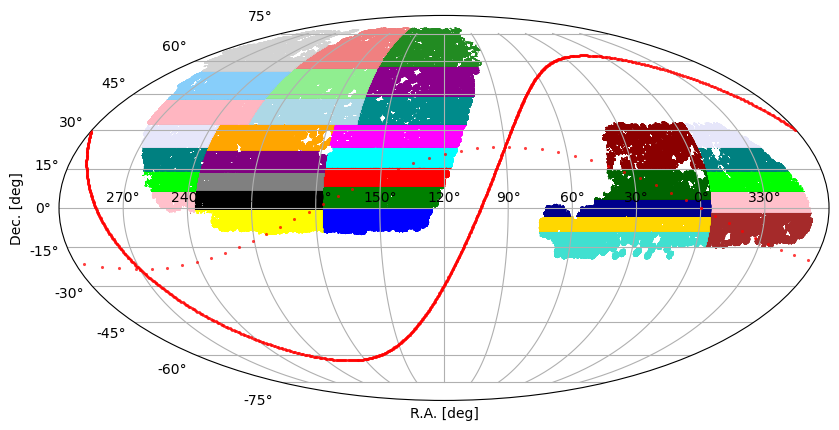

In [7]:
# Visualise the jackknife regions 'Black crosses indicate any unassigned objects'
ca.sky_plot_jack(dat)

In [8]:

def weights_to_flatten_x_histogram(x, w, bins=20, epsilon=1e-12):
    """
    Assign weights so that a weighted histogram of x is uniform.

    Parameters
    ----------
    x : array_like
        Input x values
    bins : int or array
        Number of bins or bin edges
    epsilon : float
        Small value to avoid division by zero

    Returns
    -------
    w : ndarray
        Weights for each x
    """
    counts, bin_edges = np.histogram(x, weights=w, bins=bins)
    bin_indices = np.digitize(x, bin_edges[:-1], right=False)

    # Protect against empty bins
    counts = np.maximum(counts, epsilon)

    wt = 1.0 / counts[bin_indices - 1]

    return wt

def weighted_mean_std(x, w):
    """
    Returns weighted mean and (population) weighted std.
    """
    x = np.asarray(x)
    w = np.asarray(w)

    mean = np.average(x, weights=w)
    variance = np.average((x - mean)**2, weights=w)

    return mean, np.sqrt(variance)


In [9]:
#Copilot code to fit the distribution of points (y.x) by a Gaussian whose mean and sigma vary linearly with x.

def neg_log_likelihood_linear_sigma(params, x, y, w, sigma_floor=1e-6):
    """
    Negative log-likelihood for:
        mu(x)    = a + b x
        sigma(x) = c + d x

    sigma_floor prevents numerical problems.
    """
    a, b, c, d = params

    mu = a + b * x
    sigma = c + d * x

    # hard penalty for invalid sigma
    if np.any(sigma <= sigma_floor):
        return np.inf

    nll = 0.5 * np.sum(w*
        (np.log(2 * np.pi * sigma**2) +
        (y - mu)**2 / sigma**2)
    )

    return nll


def fit_linear_gaussian_linear_sigma(x, y, w):
    """
    Fits:
        mean(x)  = a + b x
        sigma(x) = c + d x

    Returns best-fit parameters and callable functions.
    """

    # ----- initial guesses -----
    a0=20.56
    b0=0.45
    c0=0.58
    d0=0.086
    #a0, b0 = np.polyfit(x, y, 1)
    #resid = y - (a0 + b0 * x)

    # initial sigma guess: constant
    #c0 = np.std(resid)
    #d0 = 0.0

    p0 = np.array([a0, b0, c0, d0])

    # ----- optimize -----
    result = minimize(
        neg_log_likelihood_linear_sigma,
        p0,
        args=(x, y, w),
        method="Nelder-Mead",
        options={
        "maxiter": 20000,
        "xatol": 1e-8,
        "fatol": 1e-10,
    }

    )

    if not result.success:
        raise RuntimeError(result.message)

    a, b, c, d = result.x

    mean_func = lambda xx: a + b * xx
    sigma_func = lambda xx: c + d * xx

    return {
        "a": a,
        "b": b,
        "c": c,
        "d": d,
        "mean": mean_func,
        "sigma": sigma_func,
        "result": result
    }

In [18]:
#Select data and fit linear Gaussian Model

mask = (dat['ABSMAG_RP1']<-15) &  (dat['ABSMAG_RP1']>-19) & ( dat['SB']>18)  & ( dat['SB']<25) & (dat['SERSIC']<2.0)
x=dat['ABSMAG_RP1'][mask]+20.5
y=dat['SB'][mask]
wz=dat['WEIGHT_ZLOOKUP'][mask]
w=weights_to_flatten_x_histogram(x, wz,  bins=10)
w=w*wz
w=w/np.mean(w)
#w=0*w+1.0
print("Weights:",np.min(w),np.max(w),np.mean(w),np.std(w))

fit=fit_linear_gaussian_linear_sigma(x, y, w)

Weights: 0.3165833572209016 33.65544592700085 1.0 1.3881519235681756


In [19]:
# Print the fit
print(f"Mean(x)  = {fit['a']:.3f} + {fit['b']:.3f} x")
print(f"Sigma(x) = {fit['c']:.3f} + {fit['d']:.3f} x")

Mean(x)  = 20.703 + 0.319 x
Sigma(x) = 1.022 + 0.014 x


In [20]:
# Test the fit
mu_fit = fit['mean']
sigma_fit = fit['sigma']

z = (y - mu_fit(x)) / sigma_fit(x)


mean,std=weighted_mean_std(z, w)

print("weighted mean", mean)
print("weighted std", std)

weighted mean -3.32202606240725e-10
weighted std 1.000000000000556


In [21]:
# Code to compute the difference between total and fibre magnitudes for Sersic profiles with specified n_SERSIC and Effective radius R_eff.


def b_n(n):
    """
    High-accuracy Ciotti & Bertin 1999 expansion for b_n.
    """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_2d(n, Re, grid_size=200.0, npix=1600):
    """
    Construct a 2-D Sersic profile on a square grid.
    Parameters
    ----------
    n : float
        Sersic index
    Re : float
        Half-light radius (arcsec)
    grid_size : float
        Half-size of the grid (arcsec). Total grid spans [-grid_size, +grid_size].
    npix : int
        Number of pixels per dimension.
    Returns
    -------
    I : 2D ndarray
        2D Sersic intensity
    pixscale : float
        Pixel scale (arcsec/pixel)
    """
    bn = b_n(n)
    ax = np.linspace(-grid_size, grid_size, npix)
    xx, yy = np.meshgrid(ax, ax)
    rr = np.sqrt(xx**2 + yy**2)
    
    I = np.exp(-bn * (rr/Re)**(1/n))      # unnormalized Sersic profile
    pixscale = (2*grid_size) / (npix-1)
    return I, pixscale

def gaussian_psf_2d(fwhm, pixscale, npix):
    """
    Construct a normalized 2D Gaussian PSF on the same grid as the image.
    """
    sigma = fwhm / 2.355
    extent = pixscale * (npix//2)
    ax = np.linspace(-extent, extent, npix)
    xx, yy = np.meshgrid(ax, ax)
    rr2 = xx**2 + yy**2
    psf = np.exp(-0.5 * rr2 / sigma**2)
    psf /= psf.sum()   # normalize to unit integral
    return psf

def fibre_mag_difference_2d(n, Re,
                            fwhm=1.0,
                            fibre_radius=0.75,
                            npix=1600):
    """
    Compute Δm = m_fibre - m_total using proper 2D convolution.
    """
    grid_size=np.maximum(5.0*Re,5.0*fwhm)
    # --- make intrinsic Sersic image ---
    I, pixscale = sersic_2d(n, Re, grid_size, npix)
    
    # --- make PSF ---
    psf = gaussian_psf_2d(fwhm, pixscale, npix)
    
    # --- convolve 2D (FFT) ---
    Iconv = fftconvolve(I, psf, mode='same')
    
    # --- total flux ---
    Ftot = Iconv.sum() * pixscale**2
    
    # --- fibre flux ---
    ax = np.linspace(-grid_size, grid_size, npix)
    xx, yy = np.meshgrid(ax, ax)
    rr = np.sqrt(xx**2 + yy**2)
    mask = rr <= fibre_radius
    Ffib = (Iconv[mask]).sum() * pixscale**2
    
    # magnitude difference
    delta_m = -2.5 * np.log10(Ffib / Ftot)
    return delta_m

In [14]:
 n_Sersic=1.0
#Build a look up table for the difference in fibre and total magnitude as a function of Reff
ntable_bins=200
print("Building fibre mag lookup table:")
print("i , Reff, DeltaMag")
Rbins=np.linspace(0.05,50.0,ntable_bins)
dmbins=np.asarray(0.0*Rbins) # initialize array
i=0
for Re in Rbins:
    dmbins[i] = fibre_mag_difference_2d(n=n_Sersic, Re=Re)
    print(i,Rbins[i],dmbins[i])
    i += 1

fibmag_table=Table()
fibmag_table['Rbins']=Rbins
fibmag_table['dmbins']=dmbins

Building fibre mag lookup table:
i , Reff, DeltaMag
0 0.05 0.26213392796865265
1 0.30100502512562816 0.46601357892028156
2 0.5520100502512564 0.8000782862046689
3 0.8030150753768845 1.1372487841892445
4 1.0540201005025127 1.4458343648129437
5 1.3050251256281409 1.7250625874934846
6 1.556030150753769 1.9766414005183288
7 1.8070351758793972 2.204442289203728
8 2.058040201005025 2.410350579310499
9 2.309045226130653 2.5974042099440546
10 2.5600502512562815 2.77134436170902
11 2.81105527638191 2.9364348715170374
12 3.062060301507538 3.0870686550948836
13 3.3130653266331658 3.228903982738242
14 3.564070351758794 3.3620697337765777
15 3.8150753768844226 3.491192874917732
16 4.0660804020100505 3.6105659970732686
17 4.317085427135678 3.7167280956645063
18 4.568090452261306 3.8277101926928596
19 4.819095477386935 3.925921927567976
20 5.070100502512563 4.023256840148651
21 5.321105527638191 4.128040414436295
22 5.57211055276382 4.206660080697597
23 5.823115577889448 4.290311050539786
24 6.074120

In [22]:
#Assign an apparent magnitude and fibre magnitude for each of the surface brightness values
# i) Assume the apparent magnitude distribution is the same as that for the real data of the same absolute magnitude
# ii) Assume a sersic index and compute the fibre magnitude

reweight= False

def assign_fibre_mag(mu50,Mag,dat,fibmag_table):
    dat["weight_mag"]=0.0*dat["rmag"] #initialize
    magmask=(np.absolute(dat['ABSMAG_RP1']-Mag)<0.2) # Select objects of the same absolute magnitude
    mag = np.random.choice(dat["rmag"][magmask], size=len(mu50), replace=True) #select apparent magnitudes from this sample


        
    reff=Reff(mu50,mag) #compute the implied effective radius
    print("Mag bin",Mag,'Reff(stats):',np.min(reff),np.max(reff),np.mean(reff),np.std(reff))
    # Look up the magnitude difference for each reff and hence compute the fibre magnitude
    fibre_mag=mag+np.interp(reff,fibmag_table["Rbins"],fibmag_table["dmbins"])

    # Plot fibre-mag vs. mag with the magnitude cut shown
    reject = fibre_mag > 22.9 + (mag-17.8)
    reject = reject |( fibre_mag >22.9)
    select = ~reject

    if reweight:
        hist_model,bin_edges=np.histogram(mag,bins=20,density=True)
        hist_select,bin_edges=np.histogram(mag[select],bins=bin_edges,density=True)
        bin_cen=(bin_edges[1:]+bin_edges[-1])/2
        ratio = hist_model/hist_select
        valid = np.isfinite(ratio)
        ratio = np.interp(bin_cen,bin_cen[valid],ratio[valid])
        print("ratio:",ratio)
  
        dat["weight_mag"][magmask]=np.interp(dat["rmag"][magmask],bin_cen,ratio) 

        mag = np.random.choice(dat["rmag"][magmask], size=len(mu50), replace=True,p= dat["weight_mag"][magmask]/np.sum( dat["weight_mag"][magmask])) #select apparent magnitudes from this sample with weights applied


        
        reff=Reff(mu50,mag) #compute the implied effective radius
        print("Mag bin",Mag,'Reff(stats):',np.min(reff),np.max(reff),np.mean(reff),np.std(reff))
        # Look up the magnitude difference for each reff and hence compute the fibre magnitude
        fibre_mag=mag+np.interp(reff,fibmag_table["Rbins"],fibmag_table["dmbins"])

        # Plot fibre-mag vs. mag with the magnitude cut shown
        reject = fibre_mag > 22.9 + (mag-17.8)
        reject = reject |( fibre_mag >22.9)
        select = ~reject

        

    plots=True
    if plots:
        figB, axB = plt.subplots(figsize=(5,4))
        axB.scatter(mag,fibre_mag,marker='.', linewidths=0, alpha=1.0, s=0.25, color='black')
        axB.scatter(mag[select],fibre_mag[select],marker='.', linewidths=0, alpha=1.0, s=0.25, color='red')
        
        axB.set_xlim([14,19.6])
        axB.set_ylim([17,25])
        axB.set_xlabel('magnitude')
        axB.set_ylabel('fibre magnitude')
        figB.show()

        figC, axC = plt.subplots(figsize=(5,4))
        hist_model,bin_edges=np.histogram(fibre_mag-mag,bins=20,density=True)
        bin_cen=(bin_edges[1:]+bin_edges[:-1])/2
        axC.plot(bin_cen,hist_model,linestyle='solid',color='red',label='model')
        hist,bin_edges=np.histogram(dat['fib_rmag'][magmask]-dat['rmag'][magmask],bins=20,density=True)
        bin_cen=(bin_edges[1:]+bin_edges[:-1])/2
        axC.plot(bin_cen,hist,linestyle='solid',color='black',label='BGS')
        axC.set_xlabel("$\Delta M$")
        axC.legend()
        figC.show()

         
        figD, axD = plt.subplots(figsize=(5,4))
        hist_model,bin_edges=np.histogram(mag,bins=20,density=True)
        bin_cen=(bin_edges[1:]+bin_edges[:-1])/2
        axD.plot(bin_cen,hist_model,linestyle='solid',color='red',label='full')
        hist_model,bin_edges=np.histogram(mag[select],bins=20,density=True)
        bin_cen=(bin_edges[1:]+bin_edges[:-1])/2
        axD.plot(bin_cen,hist_model,linestyle='solid',color='blue',label='Selected')    
        axD.set_xlabel("$r$")
        axD.legend()
        figD.show()
    
    return fibre_mag,mag,select


dmu= 0.21212121212121104
Fit: Mag= -19.25  mean= 21.100938155740266  sigma= 1.0395742135635555
frac greater than 23.15 0.9724606052055665
njack= 29
Data        : Mag= -19.25  mean=  21.094253540039062  sigma=  1.0325857400894165
Data clipped: Mag= -19.25  mean=  21.115934371948242  sigma=  0.9061954617500305
Data clipped: Mag= -19.25  mean=  21.11711883544922  sigma=  0.8993859887123108
Data clipped: Mag= -19.25  mean=  21.117258071899414  sigma=  0.8986385464668274
Mag bin -19.25 Reff(stats): 0.10327269592771907 75.92849036978599 1.4727387660439522 1.2357752866588612
Fraction meeting Fibre limit: 0.995851
Fit: Mag= -18.75  mean= 21.26027197140358  sigma= 1.0464097788319422
frac greater than 23.15 0.9602808562513188
njack= 29
Data        : Mag= -18.75  mean=  21.18069076538086  sigma=  1.140703558921814
Data clipped: Mag= -18.75  mean=  21.21100616455078  sigma=  0.9814448356628418
Data clipped: Mag= -18.75  mean=  21.21094512939453  sigma=  0.9754393696784973
Data clipped: Mag= -18.75

/tmp/ipykernel_1125329/2232988380.py:63: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figC, axC = plt.subplots(figsize=(5,4))


Fit: Mag= -15.75  mean= 22.216274865383475  sigma= 1.087423170442263
frac greater than 23.15 0.7938591426044574
njack= 29
Data        : Mag= -15.75  mean=  21.980730056762695  sigma=  1.3890243768692017
Data clipped: Mag= -15.75  mean=  22.05731964111328  sigma=  1.0161371231079102
Data clipped: Mag= -15.75  mean=  22.06330680847168  sigma=  1.0025346279144287
Data clipped: Mag= -15.75  mean=  22.063438415527344  sigma=  1.002003788948059
Mag bin -15.75 Reff(stats): 0.16559908276230942 81.7690009623349 2.332505719874152 1.8848209218381569
Fraction meeting Fibre limit: 0.967667
Fit: Mag= -15.25  mean= 22.375608681046792  sigma= 1.0942587357106497
frac greater than 23.15 0.7497768630256422
njack= 29
Data        : Mag= -15.25  mean=  22.036888122558594  sigma=  1.5837112665176392
Data clipped: Mag= -15.25  mean=  22.162729263305664  sigma=  1.0046483278274536
Data clipped: Mag= -15.25  mean=  22.17286491394043  sigma=  0.9842396974563599
Data clipped: Mag= -15.25  mean=  22.17198371887207

/tmp/ipykernel_1125329/3805472437.py:74: RuntimeWarning: invalid value encountered in true_divide
  hist=(hist/dmu)/hist.sum()


frac greater than 23.15 0.40003924478384256
njack= 29
Data        : Mag= -11.75  mean=  21.362972259521484  sigma=  4.238516807556152
Data clipped: Mag= -11.75  mean=  21.362972259521484  sigma=  4.238516807556152
Data clipped: Mag= -11.75  mean=  21.362972259521484  sigma=  4.238516807556152
Data clipped: Mag= -11.75  mean=  21.362972259521484  sigma=  4.238516807556152
Mag bin -11.75 Reff(stats): 0.2155641169110914 66.47715190173157 4.192568600269316 2.712571997402101
Fraction meeting Fibre limit: 0.782612


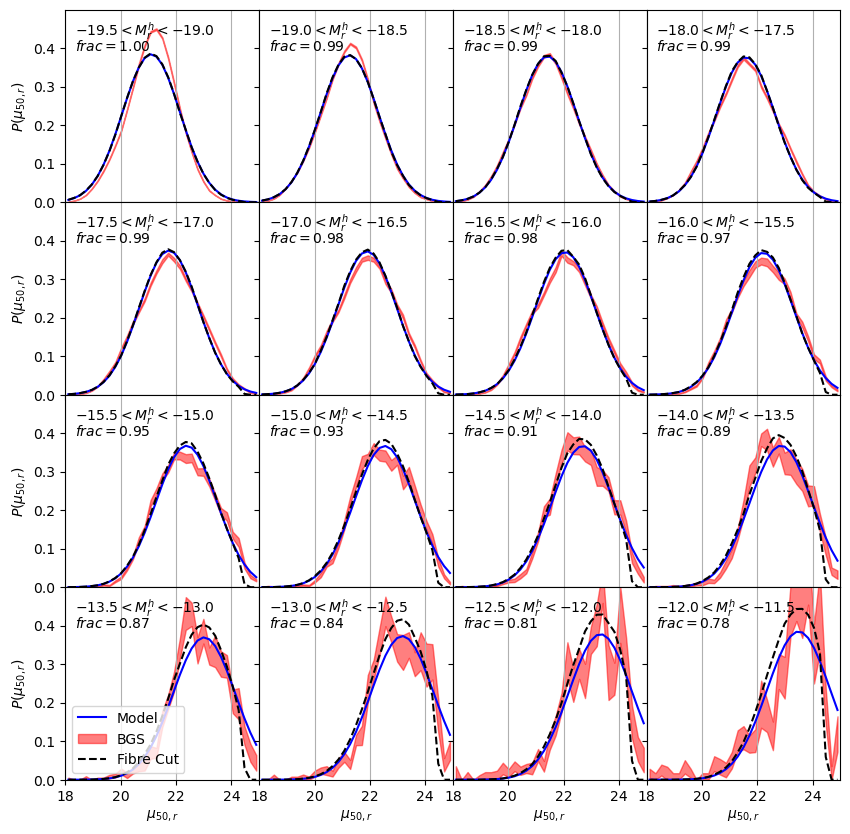

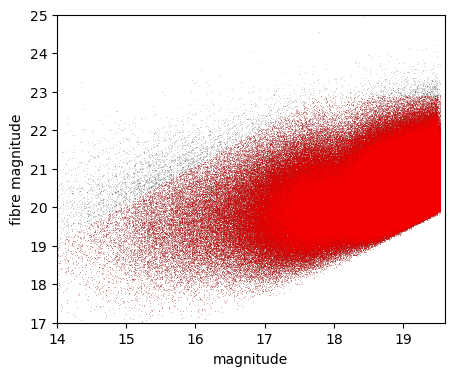

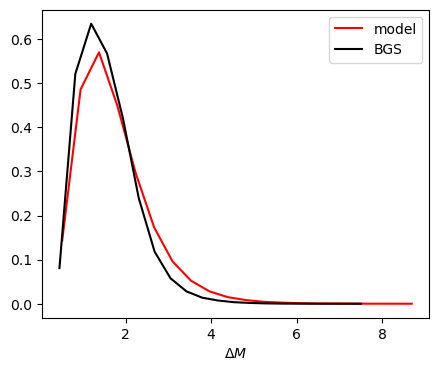

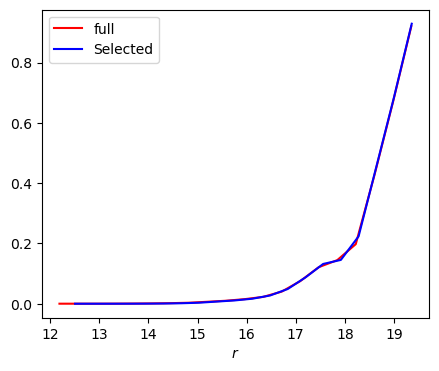

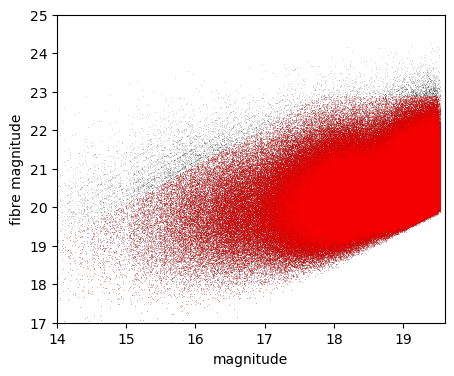

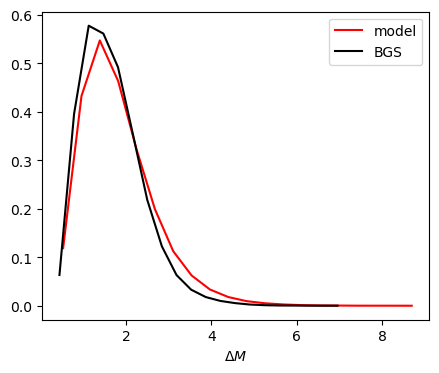

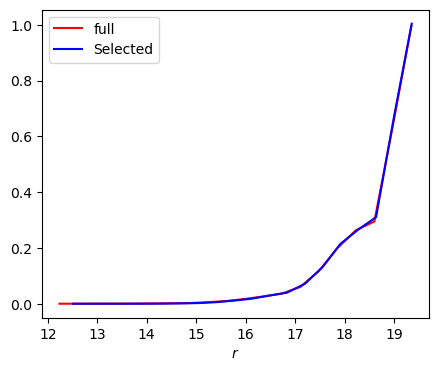

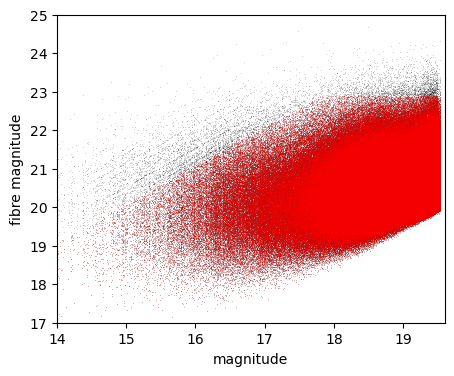

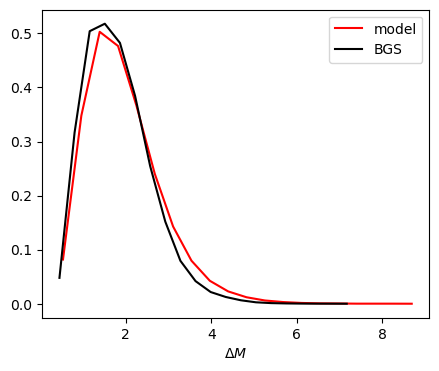

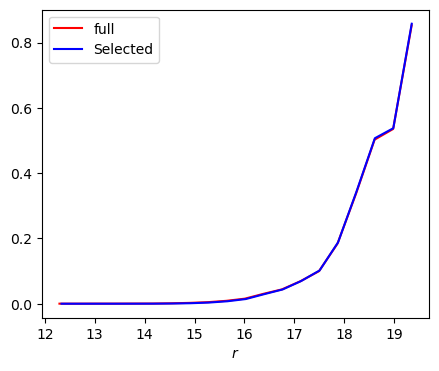

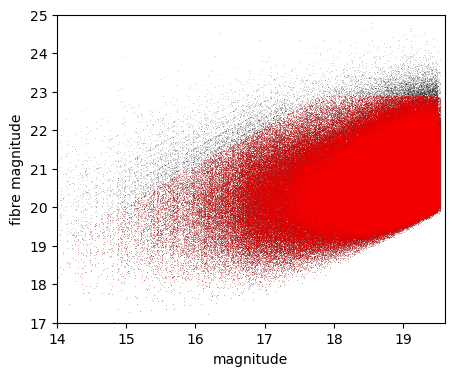

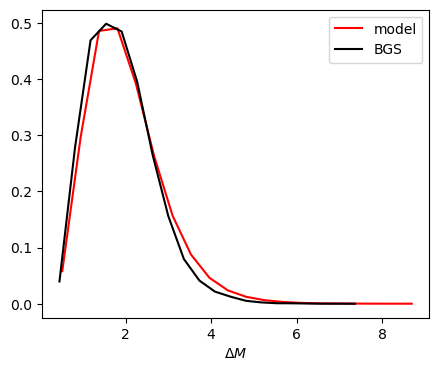

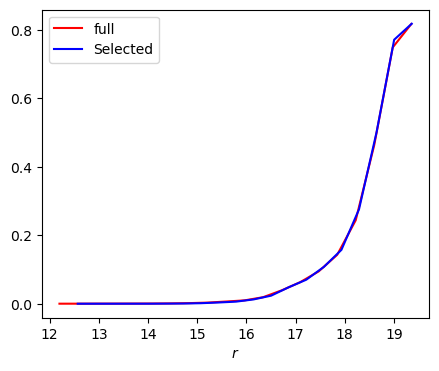

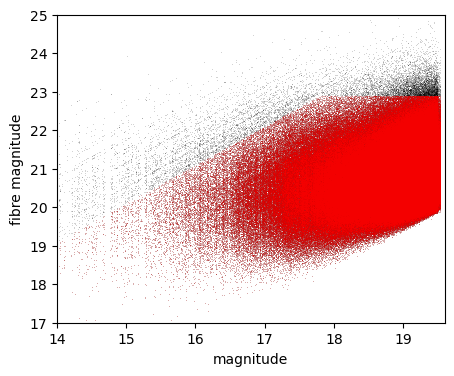

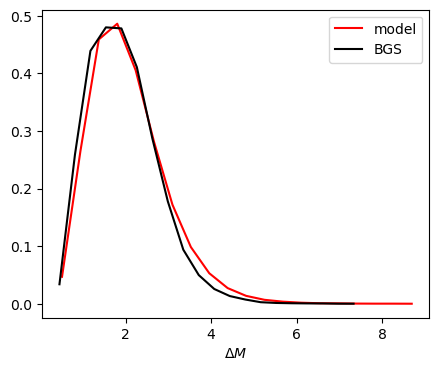

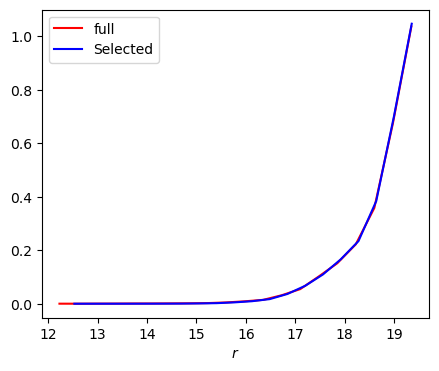

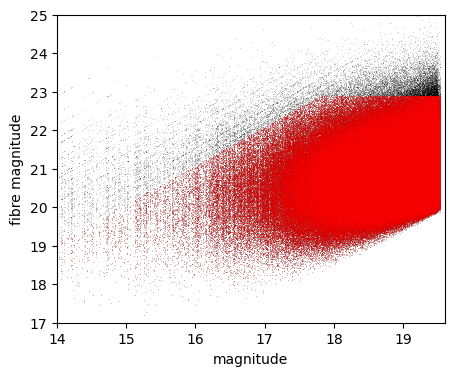

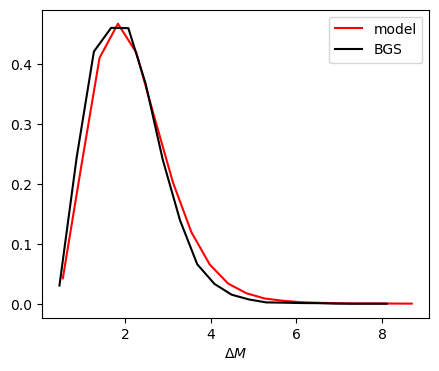

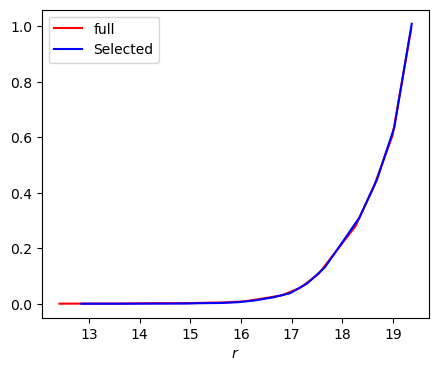

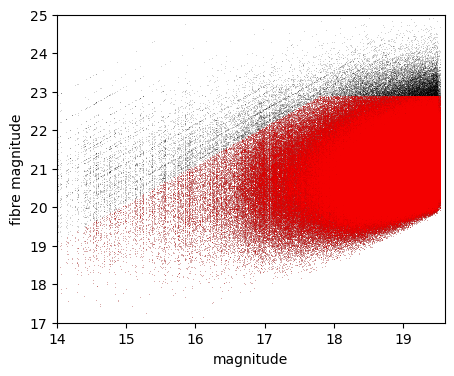

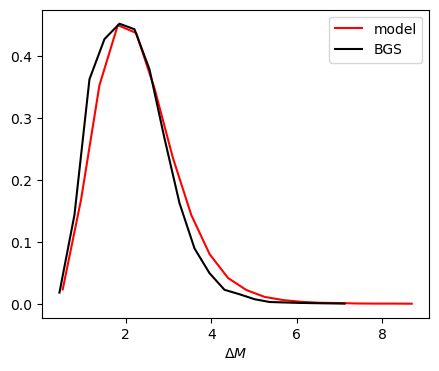

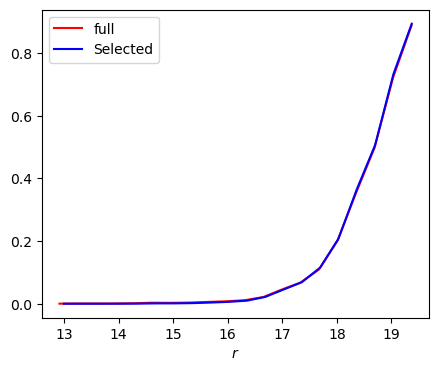

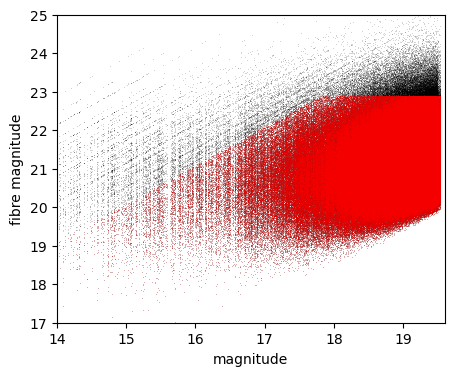

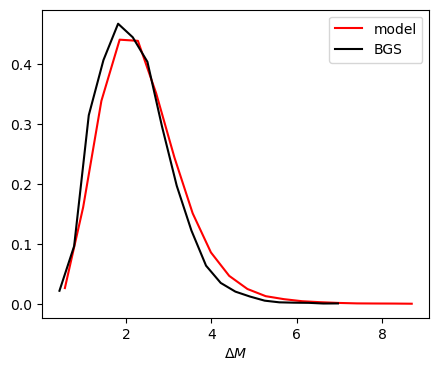

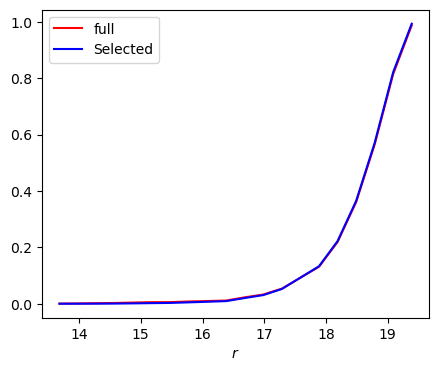

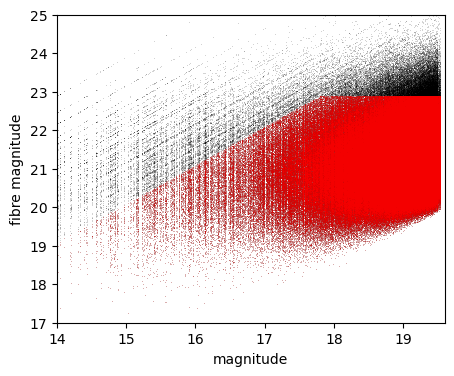

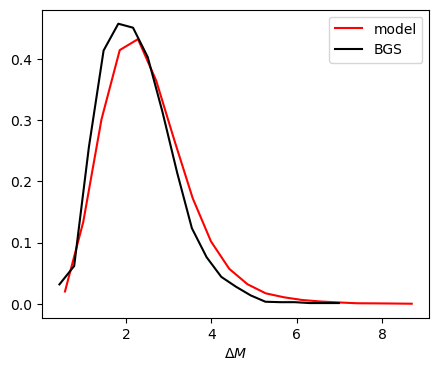

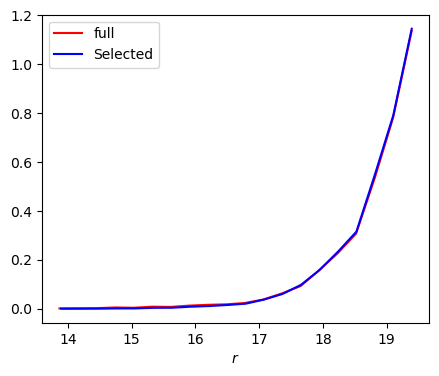

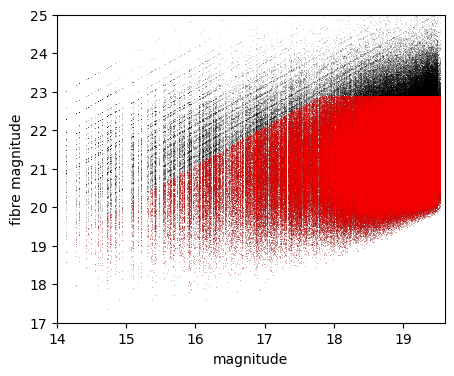

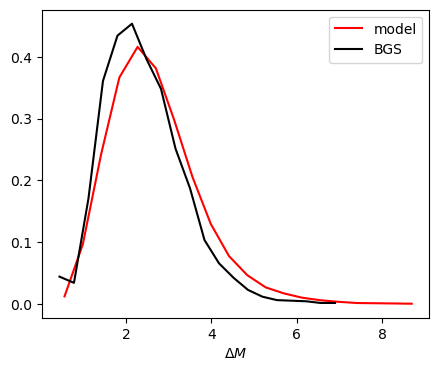

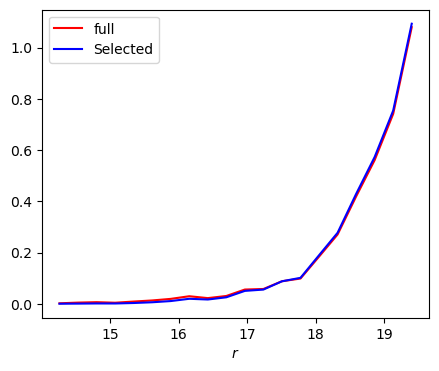

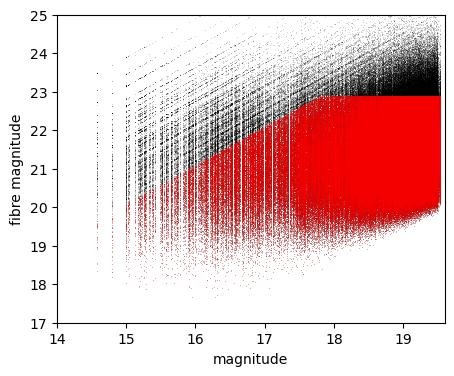

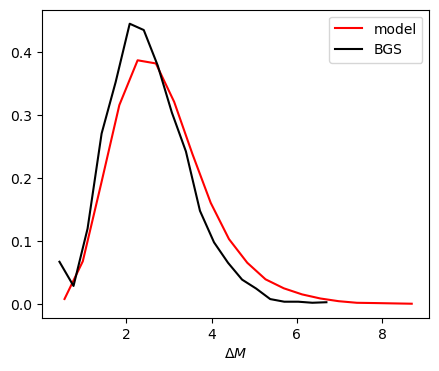

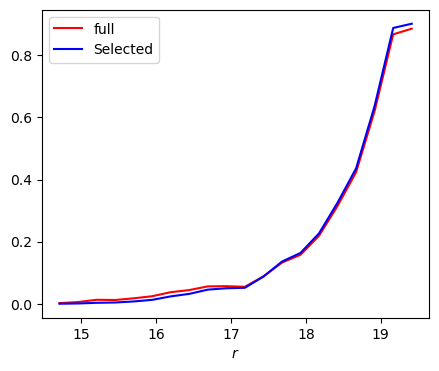

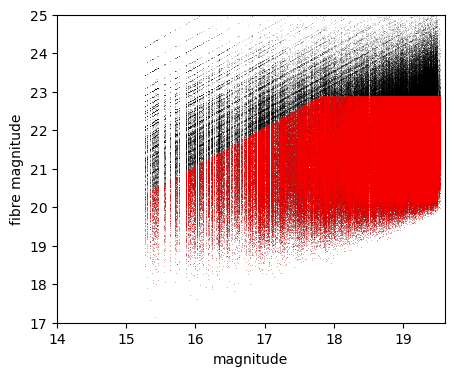

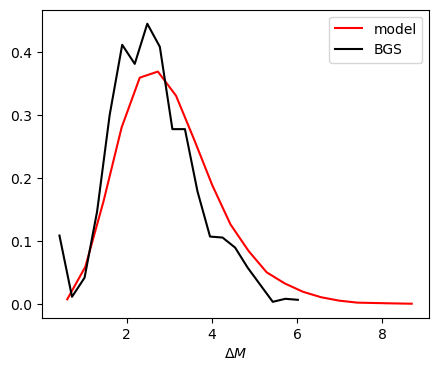

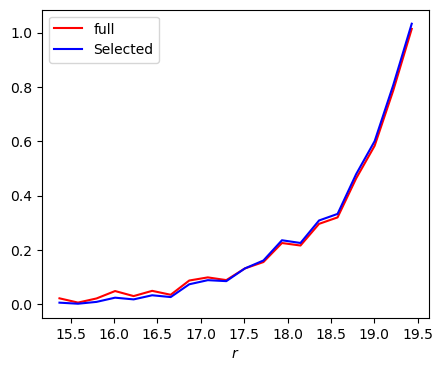

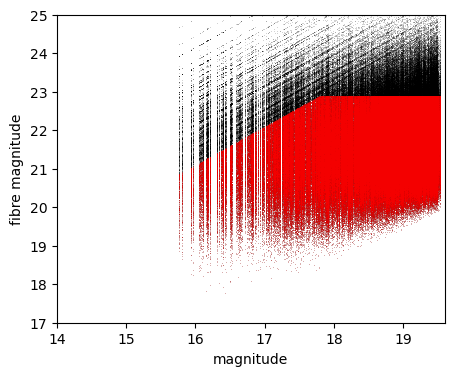

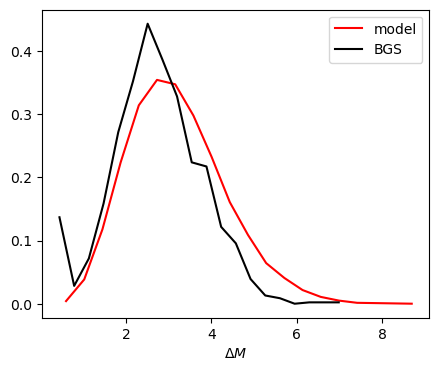

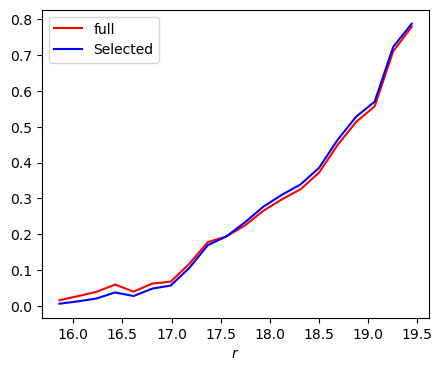

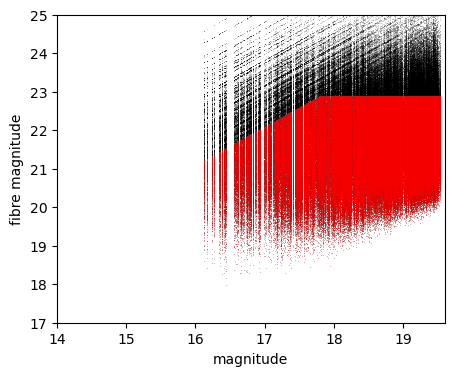

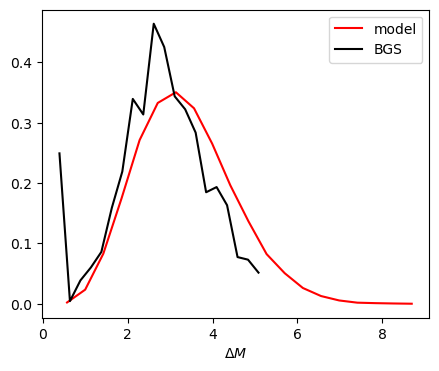

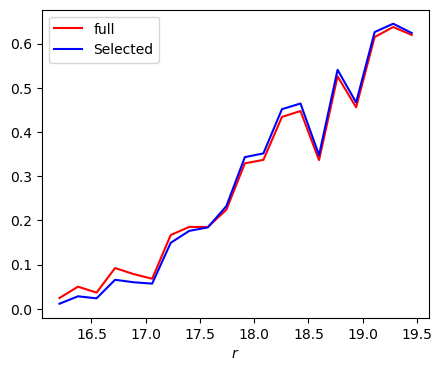

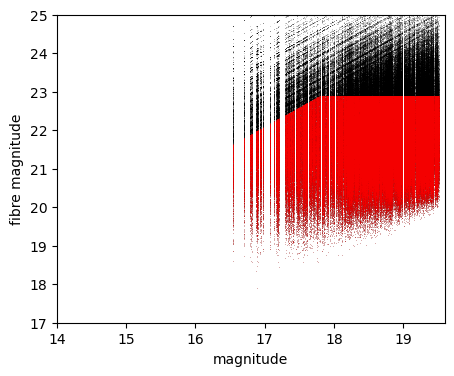

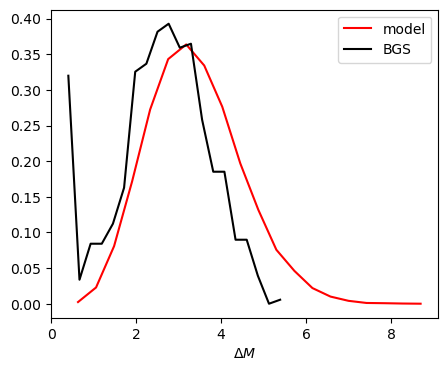

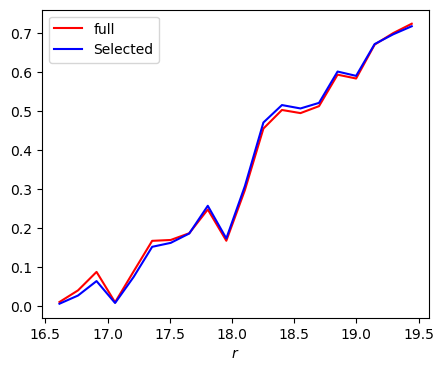

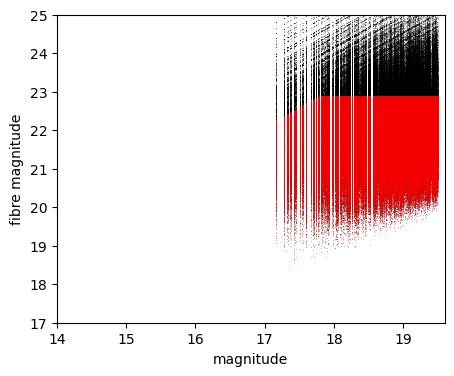

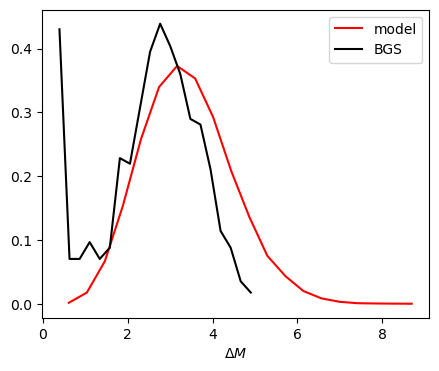

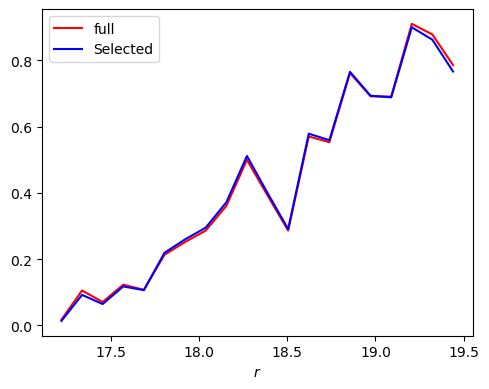

In [29]:
# A total magntude version of Fig 5 of Blanton et al(2005) with probability distributions rather than numbers



nsamp=1000000  #size of random sample that is constructed
fig, axes = plt.subplots(4, 4, figsize=(10, 10),sharex=True,sharey=True,gridspec_kw=dict(wspace=0, hspace=0))



# Remove spacing between subplots
#fig.subplots_adjust(wspace=0, hspace=0)

i=0

Magbins=np.linspace(-19.25,-11.75,16)
dMag=Magbins[1]-Magbins[0]
data_mean=0*Magbins
data_sigma=0*Magbins
data_mean_clipped=0*Magbins
data_sigma_clipped=0*Magbins
fit_mean=0*Magbins
fit_sigma=0*Magbins
mubins=np.linspace(18,25,34)
dmu=mubins[1]-mubins[0]
print("dmu=",dmu)

rng = np.random.default_rng() #Random number Generator

for ax in axes.flat:
    Mag=Magbins[i]

    Mag_u=Mag+0.5*dMag
    Mag_l=Mag-0.5*dMag

    

    
    ax.text(
        0.05, 0.95,
        fr'${Mag_l:.1f}<M^h_r< {Mag_u:.1f}$',
        transform=ax.transAxes,
        ha='left',
        va='top'
    )

    # Plot the Gaussian fit
    mubin_cen=(mubins[1:]+mubins[:-1])/2
    y=mubin_cen
    sigma_x=fit['sigma'](20.5+Mag)
    mean_x=fit['mean'](20.5+Mag)
    fit_mean[i]=mean_x
    fit_sigma[i]=sigma_x
    print("Fit: Mag=",Mag,' mean=',mean_x,' sigma=',sigma_x)
    hist_y=np.exp(-0.5*((y-mean_x)/sigma_x)**2 )
    hist_y=(hist_y/dmu)/hist_y.sum()
    ax.plot(y,hist_y,linestyle='solid',color='blue',label='Model')
    
    #Sample constructed from Blanton (2005) model
    mubar50_Petro,Reff_Petro,sigmu=Blanton_2005(Mag)
    mu50 = rng.normal(loc=mubar50_Petro, scale=sigmu, size=nsamp)

    mask= (np.absolute(sdss["ABSMAG"][:,2]-Mag) < 0.25) # select absolute magnitude bin
    nsdss=mask.sum()

    bgsmask_petro =(np.absolute(dat["PETRO_ABSMAG_RP1"]-Mag)<0.25) & (dat['SERSIC']<2.0)
    ndesi_petro=bgsmask_petro.sum()

    bgsmask =(np.absolute(dat["ABSMAG_RP1"]-Mag)<0.25) & (dat['SERSIC']<2.0)
    ndesi=bgsmask.sum()
    
    # Plot SDSS data
    hist,bin_edges=np.histogram(sdss["mu50sec"][mask],bins=mubins)
    mubin_cen=(bin_edges[1:]+bin_edges[:-1])/2
    hist=(hist/dmu)/hist.sum()
    #ax.plot(mubin_cen,hist,drawstyle='steps-mid',linestyle='solid',color='black',label=f"SDSS DR6")
    sdssmumask= (mubin_cen<23.15)
    frac=hist_y[sdssmumask].sum()/hist_y.sum()
    print("frac greater than 23.15",frac)
    hist=hist*frac
    #ax.plot(mubin_cen,hist,drawstyle='steps-mid',linestyle='solid',color='purple',label=f"SDSS DR6 scaled")
          
    # Plot sample drawn from Blanton (2005) model
    hist,bin_edges=np.histogram(mu50,bins=mubins)
    hist=(hist/dmu)/hist.sum()
    #ax.plot(mubin_cen,hist,linestyle='dotted',color='cyan',label=f"Blanton et al (2005)")

    # Plot DESI BGS within jackkife error band
    hist,bin_edges=np.histogram(dat['SB'][bgsmask],weights=dat['WEIGHT_ZLOOKUP'][bgsmask],bins=mubins)
    hist=(hist/dmu)/hist.sum()
    #ax.plot(mubin_cen,hist,linestyle='solid',color='red',label=f"BGS")
    njack=np.max(dat["ijack"][bgsmask]) + 1
    print("njack=",njack)
    histjack=np.zeros((njack,mubin_cen.size),dtype=float)
    for ijack in range(np.min(dat["ijack"][bgsmask]), np.max(dat["ijack"][bgsmask]) + 1):
        #print("ijack,njack:",ijack,njack)
        jkmask= (dat["ijack"]!=ijack) & bgsmask  # exlcude one region
        hist,bin_edges=np.histogram(dat['SB'][jkmask],weights=dat['WEIGHT_ZLOOKUP'][jkmask],bins=mubins)
        hist=(hist/dmu)/hist.sum()
        histjack[ijack,:]=hist
    hist= np.mean(histjack,axis=0)   
    hist_err=np.std(histjack,axis=0)*np.sqrt(njack-1) 
    ax.fill_between(mubin_cen,hist-hist_err,hist+hist_err,linestyle='solid',color='red',alpha=0.5,label=f"BGS")
    
    # Compute mean and sigma wihout and with clipping
    data_mean[i]=np.mean(dat['SB'][bgsmask])
    data_sigma[i]=np.std(dat['SB'][bgsmask])
    print("Data        : Mag=",Mag,' mean= ', data_mean[i],' sigma= ', data_sigma[i])
    clip = (np.absolute(dat['SB'][bgsmask]-data_mean[i]) < 3.0* data_sigma[i] )
    data_mean_clipped[i]=np.mean(dat['SB'][bgsmask][clip])
    data_sigma_clipped[i]=np.std(dat['SB'][bgsmask][clip])
    print("Data clipped: Mag=",Mag,' mean= ', data_mean_clipped[i],' sigma= ', data_sigma_clipped[i])
    clip = (np.absolute(dat['SB'][bgsmask]-data_mean_clipped[i]) < 3.0* data_sigma_clipped[i] )
    data_mean_clipped[i]=np.mean(dat['SB'][bgsmask][clip])
    data_sigma_clipped[i]=np.std(dat['SB'][bgsmask][clip])
    print("Data clipped: Mag=",Mag,' mean= ', data_mean_clipped[i],' sigma= ', data_sigma_clipped[i])
    clip = (np.absolute(dat['SB'][bgsmask]-data_mean_clipped[i]) < 3.0* data_sigma_clipped[i] )
    data_mean_clipped[i]=np.mean(dat['SB'][bgsmask][clip])
    data_sigma_clipped[i]=np.std(dat['SB'][bgsmask][clip])
    print("Data clipped: Mag=",Mag,' mean= ', data_mean_clipped[i],' sigma= ', data_sigma_clipped[i])

    # Plot DESI BGS converted to Petrosian to compare to SDSS
    hist,bin_edges=np.histogram(dat['PETRO_SB'][bgsmask_petro],bins=mubins)
    hist=(hist/dmu)/hist.sum()
    #ax.plot(mubin_cen,hist,linestyle='solid',color='green',label="DESI")

   


    # PLot a sample from the Gaussian Fit
    mu50 = rng.normal(loc=mean_x, scale=sigma_x, size=nsamp)
    hist,bin_edges=np.histogram(mu50,bins=mubins)
    hist=(hist/dmu)/hist.sum()
    #ax.plot(mubin_cen,hist,drawstyle='steps-mid',linestyle='dotted',color='cyan',label=f"mu={mean_x:.2f},sig={sigma_x:.2f}")
    
    # For objects in the Gaussian sample compute the fibre magnitude and apply the cut before replotting
    fibre_mag,mag,selected=assign_fibre_mag(mu50,Mag,dat,fibmag_table)
    frac=selected.sum()/nsamp
    print("Fraction meeting Fibre limit:",frac)
    hist,bin_edges=np.histogram(mu50[selected],bins=mubins)
    hist=(hist/dmu)/hist.sum()
    ax.plot(mubin_cen,hist,linestyle='dashed',color='black',label="Fibre Cut")
    
    ax.text(
        0.05, 0.85,
        fr'$frac= {frac:.2f}$',
        transform=ax.transAxes,
        ha='left',
        va='top'
    )
    


#    ax.grid(True)
    if (i>11): ax.set_xlabel("$\mu_{50,r}$") # put x-axis label just on the bottom row of plots
    if (i%4==0): ax.set_ylabel("$P(\mu_{50,r})$")
    ax.set_xticks([18, 20, 22, 24])
    ax.set_xlim([18,24.999])
    ax.set_ylim([0,0.4999])
    
 
    if (i==12): ax.legend(loc="lower left")
    i+= 1 #Next Magnitude bin

for ax in axes.flat:
    ax.grid(axis="x")


plt.tight_layout()

figfile="./sdata/SBdist_16.pdf"
fig.savefig(figfile, bbox_inches='tight')
plt.show()


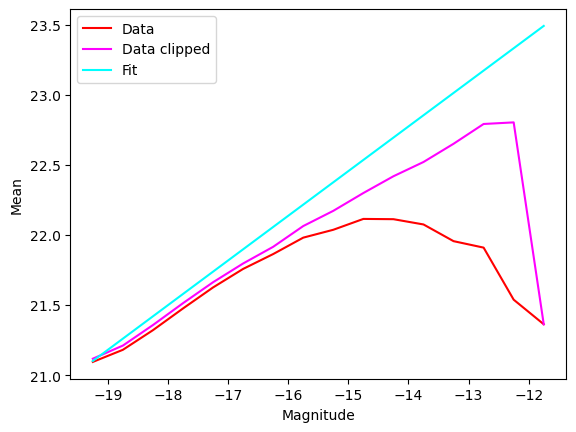

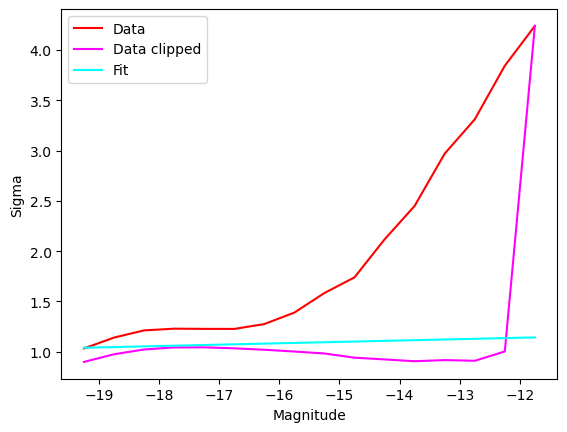

In [28]:
# Plot the model of the Fit

plt.plot(Magbins,data_mean,linestyle='solid',color='red',label='Data')
plt.plot(Magbins,data_mean_clipped,linestyle='solid',color='magenta',label='Data clipped')
plt.plot(Magbins,fit_mean,linestyle='solid',color='cyan',label='Fit')
plt.xlabel("Magnitude")
plt.ylabel("Mean")
plt.legend()
plt.show()

plt.plot(Magbins,data_sigma,linestyle='solid',color='red',label='Data')
plt.plot(Magbins,data_sigma_clipped,linestyle='solid',color='magenta',label='Data clipped')
plt.plot(Magbins,fit_sigma,linestyle='solid',color='cyan',label='Fit')
plt.xlabel("Magnitude")
plt.ylabel("Sigma")
plt.legend()
plt.show()